### Detección de Rubus niveus en la Isla Santa Cruz para priorizar zonas de control del Parque Nacional Galápagos

Algunas islas del Archipiélago de Galapagos tienen un problema serio de especies invasoras, entre esas esta la vegetación de la Rubus niveus (mora), que esta desplazando a la vegetación nativa de las islas Galápagos, pero su control es algo complicado. Debido a esto, este proyecto tendra como objetivo tratar de ayudar a la detección de zonas con posible presencia de este tipo de vegetación, para agilizar el proceso de control de esta especie invasora, empezando por zonas de la Isla Santa Cruz de Galápagos.

In [42]:
%pip install rasterio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2
from rasterio.windows import Window

In [44]:
path_b5 = 'MidTerm\\satelite\\LC09_L2SP_018060_20251215_20251217_02_T1_SR_B5.TIF' # NIR
path_b4 = 'MidTerm\\satelite\\LC09_L2SP_018060_20251215_20251217_02_T1_SR_B4.TIF' # Red
path_b3 = 'MidTerm\\satelite\\LC09_L2SP_018060_20251215_20251217_02_T1_SR_B3.TIF' # Green

Se usaron datos de Landsat 9 Nivel 2 (sacados de EarthExplorer), los cuales ya vienen con corrección atmosférica (Surface Reflectance), lo que hace que los cálculos de visión computacional sean más precisos.

Además, se escogió una escena de Diciembre del 2025 ya que en Galápagos es temporada seca, lo que hace que la vegetación de la mora (Rubus Niveus) resalte más frente a la vegetación nativa.

In [45]:
def leer_zona_galapagos(archivo, col_off=4900, row_off=5300, width=1500, height=1500):
    """Lee una ventana específica de la imagen para no saturar la RAM"""
    with rasterio.open(archivo) as src:
        # Definimos una ventana (ajusta col_off/row_off para centrar en Santa Cruz)
        ventana = Window(col_off, row_off, width, height)
        datos = src.read(1, window=ventana)
        return datos.astype(float)

Como el archivo es muy grande, usa la librería "rasterio" para leer solo una "ventana" (window) que cubra la zona alta de Santa Cruz. Esto permitirá generar las 10 imágenes requeridas sin que el notebook se trabe.

In [46]:
from pathlib import Path

def resolver_ruta(ruta_original: str) -> str:
	p = Path(ruta_original)
	if p.exists():
		return str(p)

	# Corrige posible typo común: satelite -> satellite
	p_alt = Path(str(p).replace("satelite", "satellite"))
	if p_alt.exists():
		return str(p_alt)

	# Busca por nombre de archivo dentro de carpetas cercanas
	nombre = p.name
	bases_busqueda = [Path.cwd(), Path.cwd() / "MidTerm", Path.cwd().parent]
	for base in bases_busqueda:
		if base.exists():
			encontrados = list(base.rglob(nombre))
			if encontrados:
				return str(encontrados[0])

	raise FileNotFoundError(f"No se encontró el archivo: {ruta_original}")

# Resolvemos rutas válidas antes de leer
path_b5 = resolver_ruta(path_b5)
path_b4 = resolver_ruta(path_b4)
path_b3 = resolver_ruta(path_b3)

# Cargamos las bandas necesarias
banda_nir = leer_zona_galapagos(path_b5)
banda_red = leer_zona_galapagos(path_b4)
banda_green = leer_zona_galapagos(path_b3)

print("Bandas cargadas exitosamente.")

Bandas cargadas exitosamente.


In [ ]:
# 1. Preprocesamiento: Filtro Mediano (mejor que el Gaussiano para satélites)
# Ayuda a quitar el ruido sin perder los bordes de las manchas de mora
nir_filt = cv2.medianBlur(banda_nir.astype(np.float32), 5)
red_filt = cv2.medianBlur(banda_red.astype(np.float32), 5)

# 2. Transformación: Cálculo de NDVI
# La mora en Galápagos es muy "brillante" en el NIR
ndvi = (nir_filt - red_filt) / (nir_filt + red_filt + 1e-10)

# 3. Extracción de Características: Detección de Bordes (Canny)
# Esto ayuda a visualizar la estructura de los parches invasores
# Normalizamos para que Canny funcione (0-255)
ndvi_norm = cv2.normalize(ndvi, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
bordes_mora = cv2.Canny(ndvi_norm, 50, 150)

# 4. Modelo Lógico: Segmentación por Umbral
# Consideramos "Mora Sospechosa" si NDVI > 0.5
mascara_mora = (ndvi > 0.45).astype(np.uint8)

Se eligió el filtro mediano sobre el Gaussiano porque el ruido de los sensores satelitales suele ser de tipo "sal y pimienta" (píxeles erráticos) y el filtro mediano lo elimina sin "borronear" los límites de los parches de mora.

Se usa NDVI porque la mora silvestre tiene una firma espectral de alta reflectancia en el infrarrojo cercano debido a su denso follaje, y el Filtro Mediano porque preserva mejor los bordes de las especies vegetales que un filtro promedio.

In [48]:
import cv2

# Refinamiento del Modelo
kernel = np.ones((5,5), np.uint8) 
# El 'Opening' elimina puntos de ruido blanco aislados
mascara_limpia = cv2.morphologyEx(mascara_mora, cv2.MORPH_OPEN, kernel)
# El 'Closing' rellena huecos dentro de los parches de mora
mascara_final = cv2.morphologyEx(mascara_limpia, cv2.MORPH_CLOSE, kernel)

El OPENING eliminó falsos positivos (píxeles aislados de vegetación nativa) y el CLOSING unificó los parches densos de mora para dar un cálculo de área más realista.

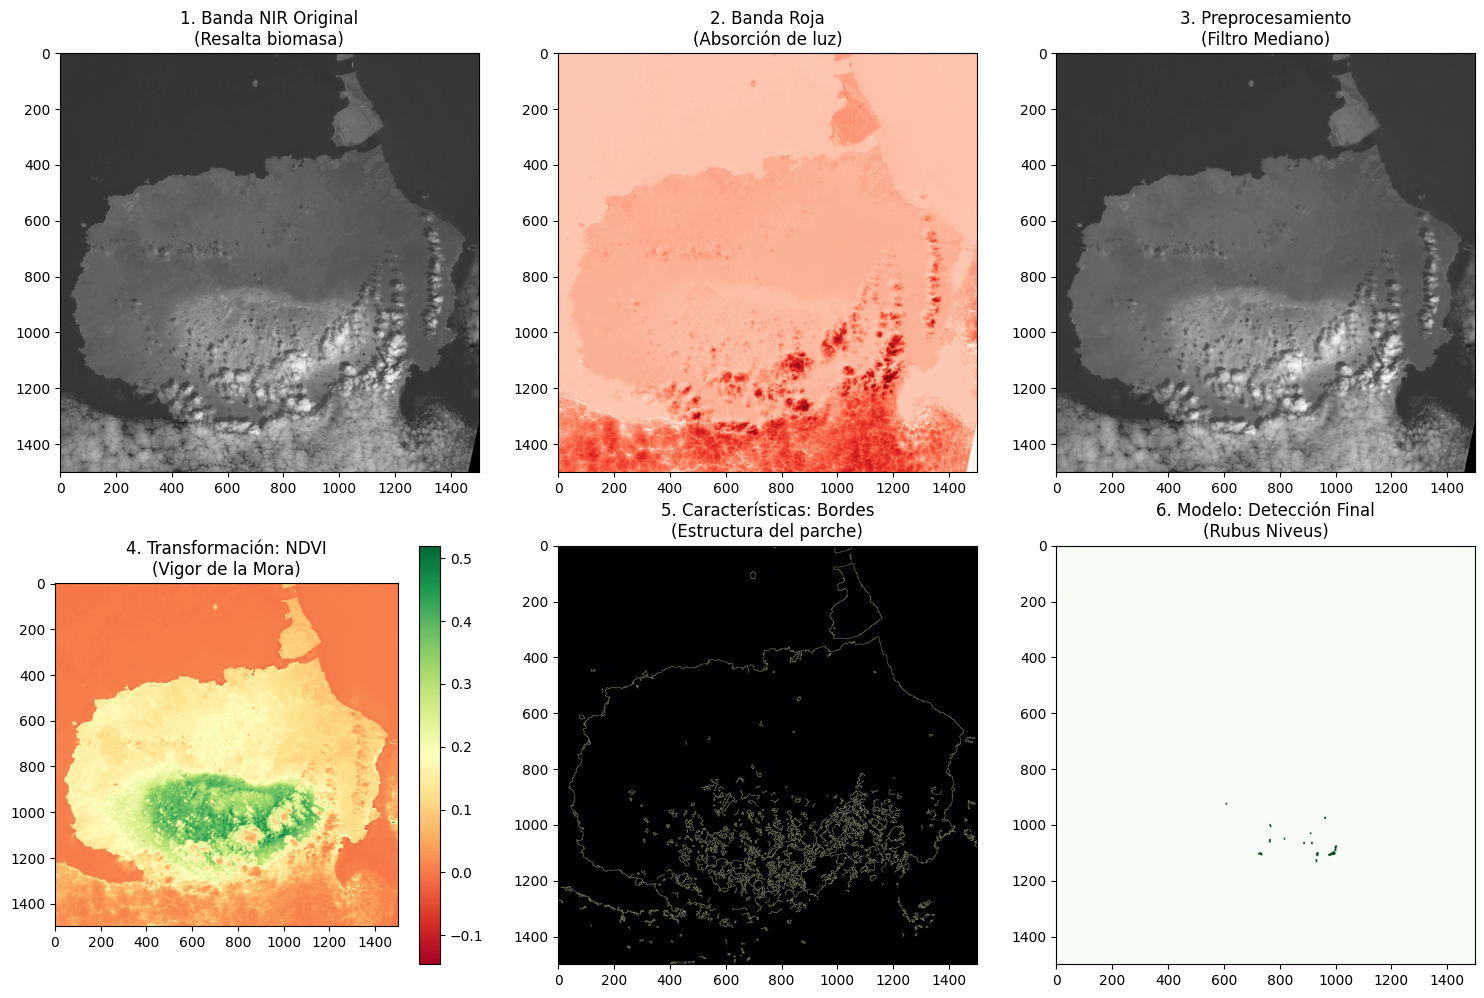

In [49]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Visualización 1: Banda NIR (Resalta vegetación)
axs[0, 0].imshow(banda_nir, cmap='gray')
axs[0, 0].set_title("1. Banda NIR Original\n(Resalta biomasa)")

# Visualización 2: Banda Roja (Absorción de clorofila)
axs[0, 1].imshow(banda_red, cmap='Reds')
axs[0, 1].set_title("2. Banda Roja\n(Absorción de luz)")

# Visualización 3: Filtro de Suavizado
axs[0, 2].imshow(nir_filt, cmap='gray')
axs[0, 2].set_title("3. Preprocesamiento\n(Filtro Mediano)")

# Visualización 4: Mapa de Calor NDVI
im4 = axs[1, 0].imshow(ndvi, cmap='RdYlGn')
axs[1, 0].set_title("4. Transformación: NDVI\n(Vigor de la Mora)")
plt.colorbar(im4, ax=axs[1, 0])

# Visualización 5: Detección de Estructura
axs[1, 1].imshow(bordes_mora, cmap='magma')
axs[1, 1].set_title("5. Características: Bordes\n(Estructura del parche)")

# Visualización 6: Resultado Final (Segmentación)
axs[1, 2].imshow(mascara_final, cmap='Greens')
axs[1, 2].set_title("6. Modelo: Detección Final\n(Rubus Niveus)")

plt.tight_layout()
plt.show()

Se observa que la mayor concentración de biomasa invasora se encuentra en la parte central-sur, donde el NDVI supera el 0.45, lo que podria significar una concentracion de Rubus Niveus en la zona.

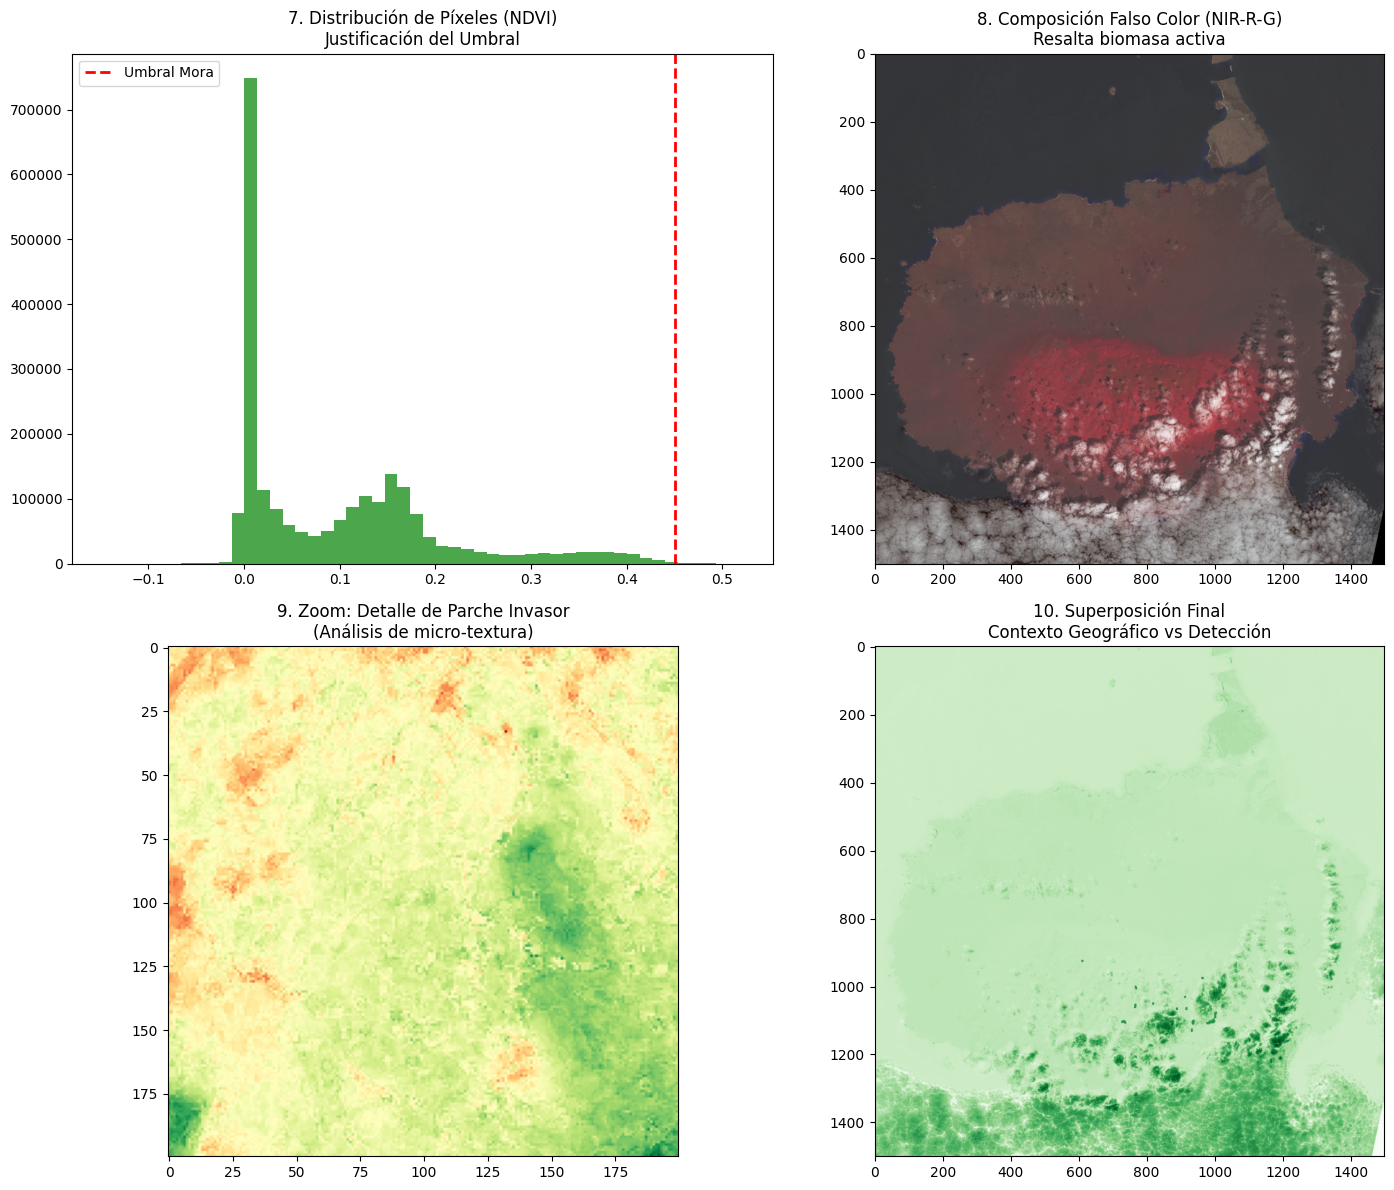

In [50]:
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# 7. Histograma del NDVI (Visualización Estadística)
axs[0, 0].hist(ndvi.flatten(), bins=50, color='green', alpha=0.7)
axs[0, 0].axvline(0.45, color='red', linestyle='dashed', linewidth=2, label='Umbral Mora')
axs[0, 0].set_title("7. Distribución de Píxeles (NDVI)\nJustificación del Umbral")
axs[0, 0].legend()

# 8. Visualización de "Falso Color" (Vegetación en Rojo)
# Combinación B5 (NIR), B4 (Red), B3 (Green) - Estándar en teledetección
# Normalizamos para visualización
false_color = np.dstack((
    cv2.normalize(banda_nir, None, 0, 255, cv2.NORM_MINMAX),
    cv2.normalize(banda_red, None, 0, 255, cv2.NORM_MINMAX),
    cv2.normalize(banda_green, None, 0, 255, cv2.NORM_MINMAX)
)).astype(np.uint8)
axs[0, 1].imshow(false_color)
axs[0, 1].set_title("8. Composición Falso Color (NIR-R-G)\nResalta biomasa activa")

# 9. Zoom en Zona de Invasión (Detalle Computacional)
# Tomamos un recorte pequeño de la zona con más NDVI
zoom_ndvi = ndvi[200:400, 200:400]
axs[1, 0].imshow(zoom_ndvi, cmap='RdYlGn')
axs[1, 0].set_title("9. Zoom: Detalle de Parche Invasor\n(Análisis de micro-textura)")

# 10. Superposición (Overlay) de Detección sobre Original
# Mostramos la máscara de mora sobre la banda verde para contexto
overlay = cv2.addWeighted(
    cv2.normalize(banda_green, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8), 0.7,
    (mascara_final * 255).astype(np.uint8), 0.3, 0
)
axs[1, 1].imshow(overlay, cmap='Greens')
axs[1, 1].set_title("10. Superposición Final\nContexto Geográfico vs Detección")

plt.tight_layout()
plt.show()

In [51]:
# Análisis de Impacto Ambiental
pixeles_detectados = np.sum(mascara_final)
# Landsat 9 tiene resolución de 30m x 30m por píxel
area_total_m2 = pixeles_detectados * 900 
area_hectareas = area_total_m2 / 10000

print(f"ANÁLISIS TÉCNICO PARA EL PARQUE NACIONAL:")
print(f"- Área total de Santa Cruz analizada: {banda_nir.size * 900 / 10000:.2f} ha")
print(f"- Área estimada con presencia de Mora: {area_hectareas:.2f} ha")

ANÁLISIS TÉCNICO PARA EL PARQUE NACIONAL:
- Área total de Santa Cruz analizada: 202500.00 ha
- Área estimada con presencia de Mora: 98.82 ha
